In [1]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load the data

In [55]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [3]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [4]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    # ***************************************************
    N,_ = tx.shape
    loss = 1/(N) * np.linalg.norm(y - tx.dot(w)) ** 2
    return loss

In [5]:
w_zero = np.array([1,2]).T
loss_zero = compute_loss(y,tx,w_zero)
print(loss_zero)

5388.966731774167


# 2. Grid Search

Fill in the function `grid_search()` below:

In [6]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss for each combination of w0 and w1.
    # ***************************************************
    num1 = len(grid_w0)
    num2 = len(grid_w1)
    losses = np.zeros((num1,num2))
    for i in range(num1):
        for j in range(num2):
            losses[i,j] = compute_loss(y,tx,np.array([grid_w0[i],grid_w1[j]]).T)
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=37.58708203904622, w0*=71.42857142857142, w1*=15.306122448979579, execution time=0.032 seconds


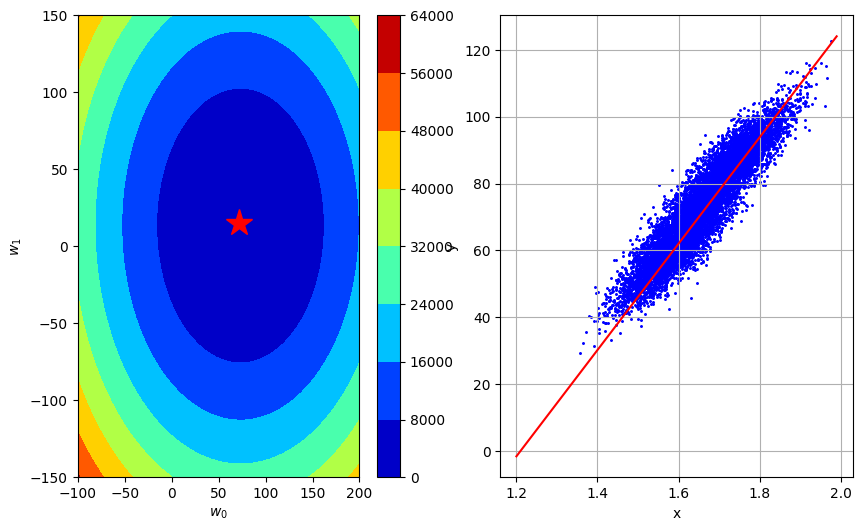

In [13]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=50)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [14]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute gradient vector
    # ***************************************************
    N,_ = tx.shape
    gradient = -1/N * (np.transpose(tx)).dot(y-tx.dot(w))
    return gradient

In [15]:
w_1 = np.array([100,20]).T
w_2 = np.array([50,10]).T

grad_1 = compute_gradient(y,tx,w_1)
grad_2 = compute_gradient(y,tx,w_2)

print(f"Grad 1 is {grad_1} and its norm is {np.linalg.norm(grad_1):2f}")
print(f"Grad 2 is {grad_2} and its norm is {np.linalg.norm(grad_2):2f}")


Grad 1 is [26.706078    6.52028757] and its norm is 27.490521
Grad 2 is [-23.293922    -3.47971243] and its norm is 23.552393


Please fill in the functions `gradient_descent` below:

In [16]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute gradient and loss
        # ***************************************************
        grad = compute_gradient(y,tx,w)
        loss = compute_loss(y,tx,w)
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by gradient
        # ***************************************************
        w = w - gamma * grad

        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [ ]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.02

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/9999: loss=5584.473425518335, w0=0.07329392200210526, w1=0.013479712434989318
GD iter. 1/9999: loss=5573.371575920422, w0=0.1465145500822081, w1=0.026945945157543616
GD iter. 2/9999: loss=5562.291918919858, w0=0.2196619575342308, w1=0.04039871164737538
GD iter. 3/9999: loss=5551.2344101536355, w0=0.2927362175788018, w1=0.05383802537071733
GD iter. 4/9999: loss=5540.199005347437, w0=0.36573740336332805, w1=0.06726389978033587
GD iter. 5/9999: loss=5529.18566031545, w0=0.4386655879620699, w1=0.08067634831554472
GD iter. 6/9999: loss=5518.1943309601775, w0=0.5115208443762131, w1=0.09407538440221841
GD iter. 7/9999: loss=5507.224973272288, w0=0.5843032455339422, w1=0.10746102145280548
GD iter. 8/9999: loss=5496.277543330416, w0=0.6570128642905133, w1=0.12083327286634199
GD iter. 9/9999: loss=5485.351997300999, w0=0.729649773428328, w1=0.134192152028465
GD iter. 10/9999: loss=5474.448291438093, w0=0.8022140456570049, w1=0.14753767231142578
GD iter. 11/9999: loss=5463.566382083207

interactive(children=(IntSlider(value=1, description='n_iter', max=10001, min=1), Output()), _dom_classes=('wi…

<function __main__.plot_figure(n_iter)>

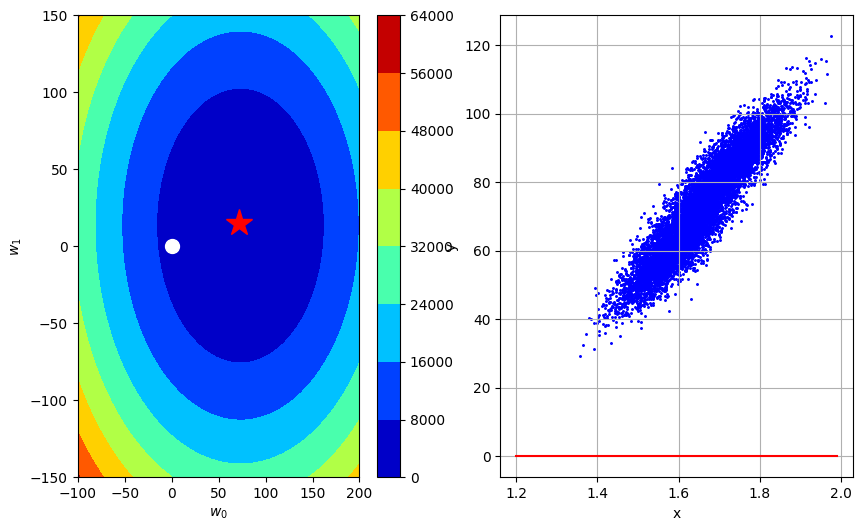

In [70]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 4. Stochastic gradient descent

In [ ]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: implement stochastic gradient computation. It's the same as the usual gradient.
    # ***************************************************
    B = len(tx)
    gradient = -1/B * (np.transpose(tx)).dot(y-tx.dot(w))
    return gradient


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        for y_batch, tx_batch in batch_iter(y,tx,batch_size, shuffle=True):
            g = compute_stoch_gradient(y_batch,tx_batch,w)
            w = w - gamma*g

        loss = compute_loss(y,tx,w)
        losses.append(loss)
        ws.append(w)

        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [72]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.02
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/499: loss=5407.346475843303, w0=1.327400598745494, w1=-0.5700027651641966
SGD iter. 1/499: loss=5147.983034152844, w0=2.975460763387961, w1=0.3448250188667261
SGD iter. 2/499: loss=5037.6859457904, w0=4.002620742093051, w1=-0.8600832311626501
SGD iter. 3/499: loss=4901.3807944362525, w0=5.151846616042606, w1=-1.5956509363781097
SGD iter. 4/499: loss=4757.163895656432, w0=6.385314014025633, w1=-2.319980505580122
SGD iter. 5/499: loss=4675.173604996929, w0=7.316439532094329, w1=-3.5899576314967145
SGD iter. 6/499: loss=4613.431554962785, w0=8.093064038744664, w1=-4.727645969425657
SGD iter. 7/499: loss=4463.502900954318, w0=9.342721380931769, w1=-5.039873530336584
SGD iter. 8/499: loss=4094.685849738167, w0=11.374389446758114, w1=-1.6822650787728701
SGD iter. 9/499: loss=3958.2066469820675, w0=12.571849045412868, w1=-2.020762625038816
SGD iter. 10/499: loss=3725.051762326955, w0=14.17087916433659, w1=-0.6180105085460843
SGD iter. 11/499: loss=3571.6869648270103, w0=15.3859610

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

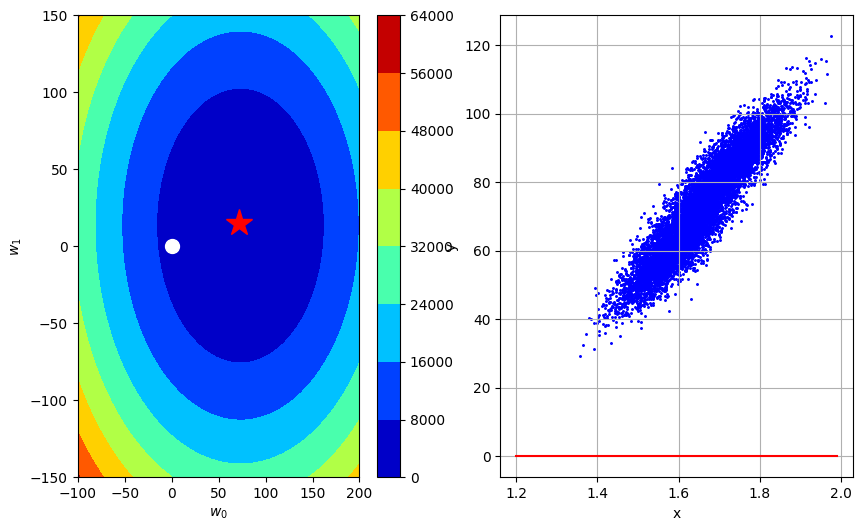

In [73]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

# 5. Effect of Outliers and MAE Cost Function

In [42]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: reload the data by subsampling first, then by subsampling and adding outliers
# ***************************************************
height, weight, gender = load_data(sub_sample=True, add_outlier=True)

x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [43]:
y.shape, tx.shape

((203,), (203, 2))

In [47]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.02

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: fit the model to the subsampled data / subsampled data with outliers and visualize the cloud of points
#       and the model fit
# ***************************************************
gd_losses_sub, gd_ws_sub = gradient_descent(y,tx,w_initial,max_iters, gamma)


end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/499: loss=5564.817663087338, w0=2.6255506607929515, w1=-5.783319735280035
SGD iter. 1/499: loss=5454.783781135618, w0=3.606410097229085, w1=-6.684190425576374
SGD iter. 2/499: loss=5314.821583037837, w0=4.708078775269999, w1=-7.112567692518195
SGD iter. 3/499: loss=5076.851520546572, w0=6.21028882443086, w1=-6.196023631486334
SGD iter. 4/499: loss=4760.035274342603, w0=8.043036375286448, w1=-3.8949243980236834
SGD iter. 5/499: loss=4653.199530631508, w0=9.04111141378649, w1=-4.736604490183201
SGD iter. 6/499: loss=4518.083006448247, w0=10.213483408487823, w1=-5.281735942416863
SGD iter. 7/499: loss=4257.800302102776, w0=11.904987549199666, w1=-3.7169707102459095
SGD iter. 8/499: loss=4008.985953559079, w0=13.477918527968132, w1=-1.5925772875804967
SGD iter. 9/499: loss=3922.81800004473, w0=14.366998752742335, w1=-2.459095536023433
SGD iter. 10/499: loss=3779.5128848958325, w0=15.502901655473186, w1=-2.1272855104440342
SGD iter. 11/499: loss=3618.2149367893157, w0=16.7550249

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

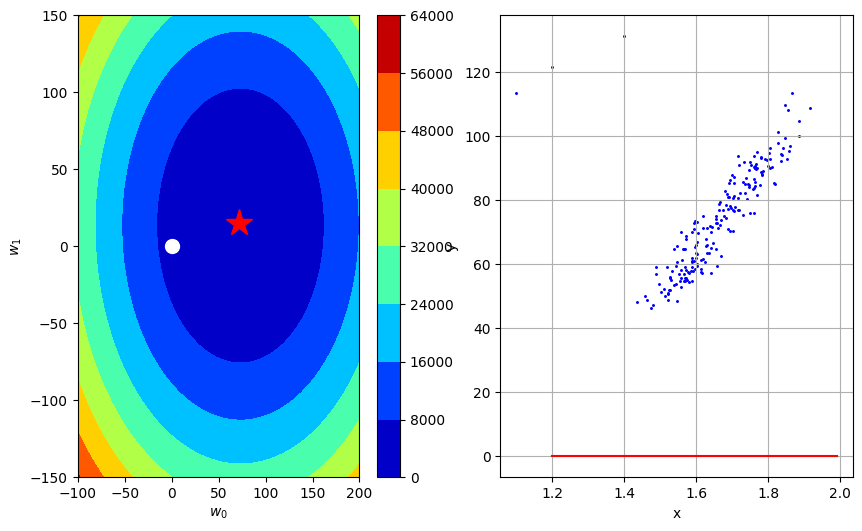

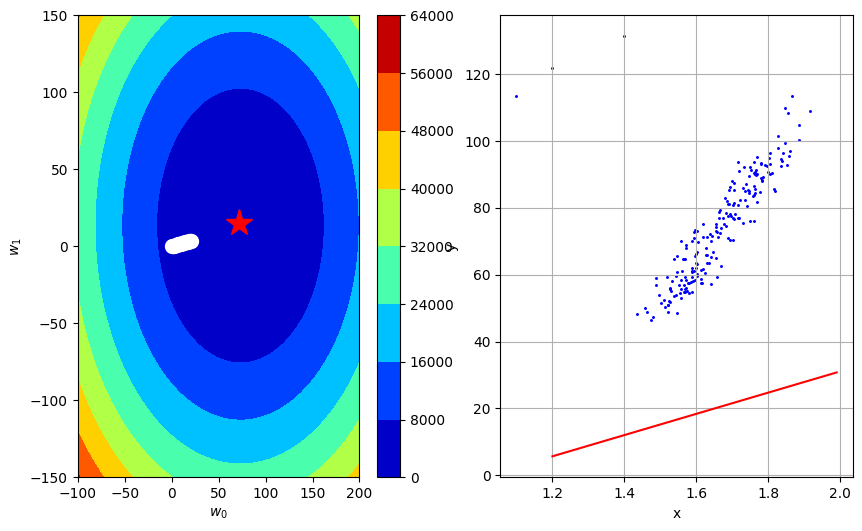

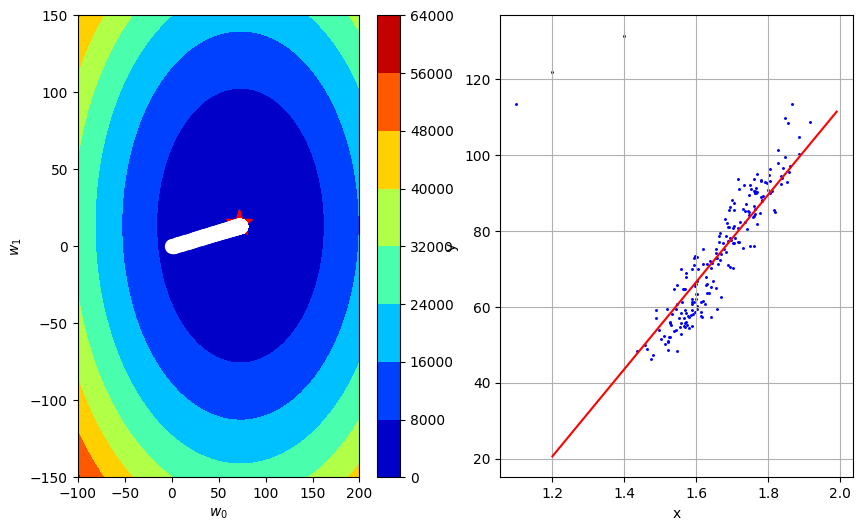

In [48]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 6. Subgradient descent

In [74]:
def compute_loss_mae(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    # ***************************************************
    N,_ = tx.shape
    loss = 1/N * np.linalg.norm(y - tx.dot(w), 1)
    return loss

In [77]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute subgradient gradient vector for MAE
    # ***************************************************
    N, _ = tx.shape
    residuals = y - tx.dot(w)
    subgradient = -(tx.T @ np.sign(residuals))/ N

    return subgradient

In [78]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: compute subgradient and loss
        # ***************************************************
        subgradient = compute_subgradient_mae(y,tx,w)
        loss = compute_loss_mae(y,tx,w)
        
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: update w by subgradient
        # ***************************************************
        w = w - subgradient*gamma
        


        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [88]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=73.29392200210519, w0=0.7, w1=2.666453724486928e-15
SubGD iter. 1/499: loss=72.59392200210519, w0=1.4, w1=5.332907448973856e-15
SubGD iter. 2/499: loss=71.89392200210519, w0=2.0999999999999996, w1=7.999361173460784e-15
SubGD iter. 3/499: loss=71.19392200210518, w0=2.8, w1=1.0665814897947712e-14
SubGD iter. 4/499: loss=70.49392200210518, w0=3.5, w1=1.333226862243464e-14
SubGD iter. 5/499: loss=69.79392200210518, w0=4.2, w1=1.5998722346921567e-14
SubGD iter. 6/499: loss=69.09392200210517, w0=4.9, w1=1.8665176071408495e-14
SubGD iter. 7/499: loss=68.39392200210517, w0=5.6000000000000005, w1=2.1331629795895423e-14
SubGD iter. 8/499: loss=67.69392200210517, w0=6.300000000000001, w1=2.399808352038235e-14
SubGD iter. 9/499: loss=66.99392200210518, w0=7.000000000000001, w1=2.666453724486928e-14
SubGD iter. 10/499: loss=66.29392200210519, w0=7.700000000000001, w1=2.9330990969356204e-14
SubGD iter. 11/499: loss=65.59392200210519, w0=8.4, w1=3.1997444693843135e-14
SubGD it

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

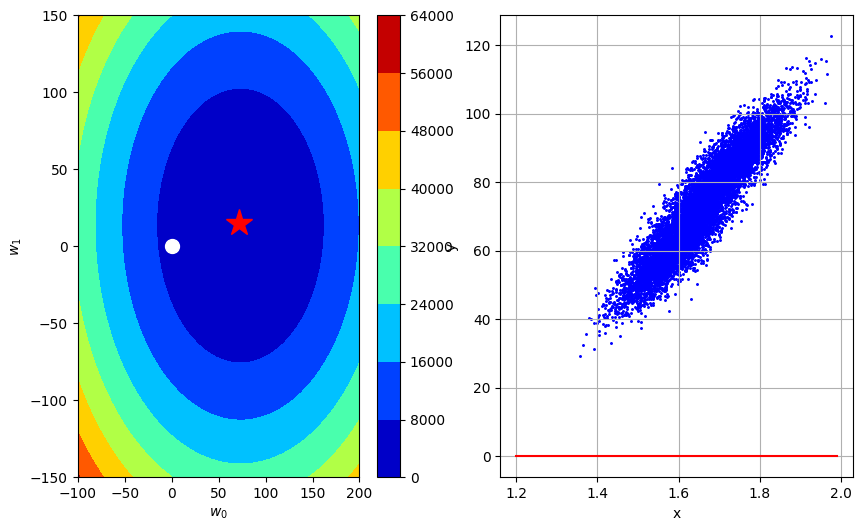

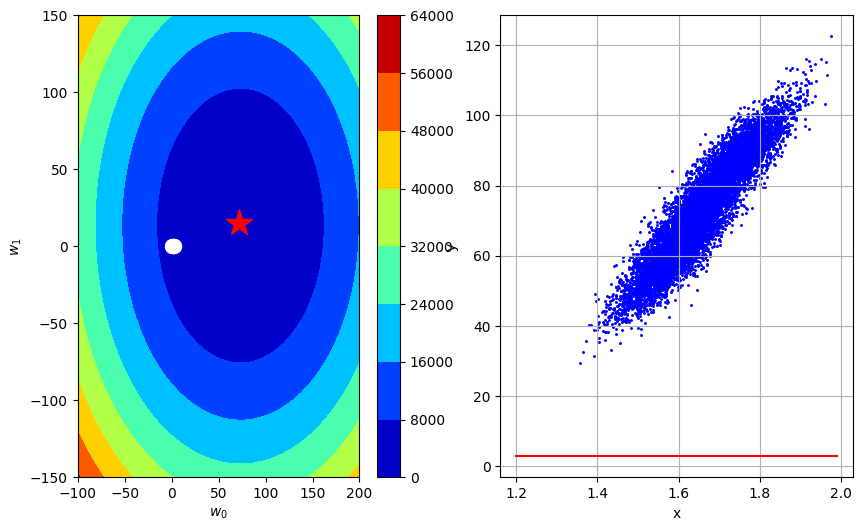

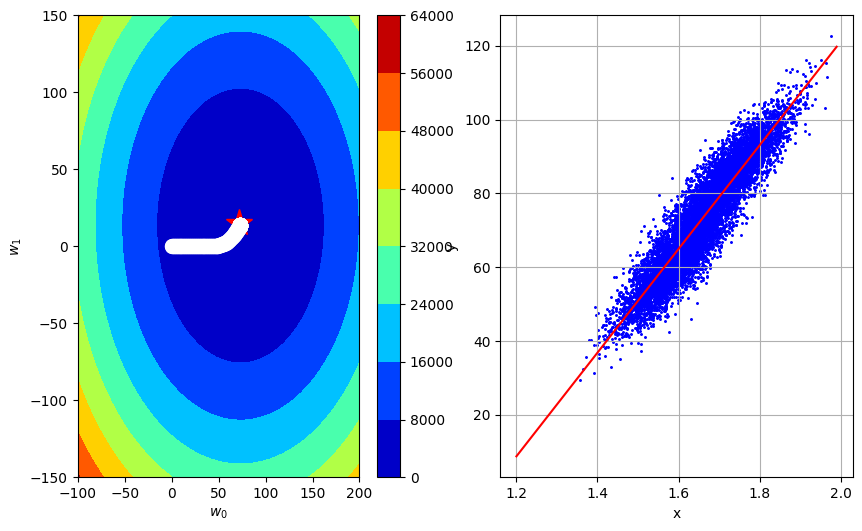

In [89]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

In [ ]:
# Check for finding the non-differentiable points encoutered
for n in range(max_iters):
    for i in range(len(y)):
        if y[i] == tx[i,:].dot(subgd_ws[n]):
            print("Yes")

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [ ]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):
        # ***************************************************
        # INSERT YOUR CODE HERE
        # TODO: implement stochastic subgradient descent.
        # ***************************************************
        for y_batch, tx_batch in batch_iter(y,tx,batch_size,shuffle=True):
            g = compute_subgradient_mae(y_batch,tx_batch,w)
            w -= gamma*g
        
        ws.append(w)
        loss = compute_loss_mae(y,tx,w)
        losses.append(loss)

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [83]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0], dtype=float)

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=72.59392200210519, w0=0.7, w1=0.3082000997227944
SubSGD iter. 1/499: loss=71.89392200210517, w0=1.4, w1=1.5007182925680778
SubSGD iter. 2/499: loss=71.19392200210517, w0=2.0999999999999996, w1=1.1550844803268512
SubSGD iter. 3/499: loss=70.49392200210518, w0=2.8, w1=1.6574784981868431
SubSGD iter. 4/499: loss=69.79392200210519, w0=3.5, w1=0.6296091083453945
SubSGD iter. 5/499: loss=69.09392200210519, w0=4.2, w1=1.0607549192943608
SubSGD iter. 6/499: loss=68.39392200210517, w0=4.9, w1=1.1828949823729067
SubSGD iter. 7/499: loss=67.69392200210517, w0=5.6000000000000005, w1=1.8330564074890612
SubSGD iter. 8/499: loss=66.99392200210517, w0=6.300000000000001, w1=1.9179524986591387
SubSGD iter. 9/499: loss=66.29392200210516, w0=7.000000000000001, w1=2.874166543966617
SubSGD iter. 10/499: loss=65.59392200210516, w0=7.700000000000001, w1=2.681039243712593
SubSGD iter. 11/499: loss=64.89392200210516, w0=8.4, w1=2.001559134580406
SubSGD iter. 12/499: loss=64.193922002105

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

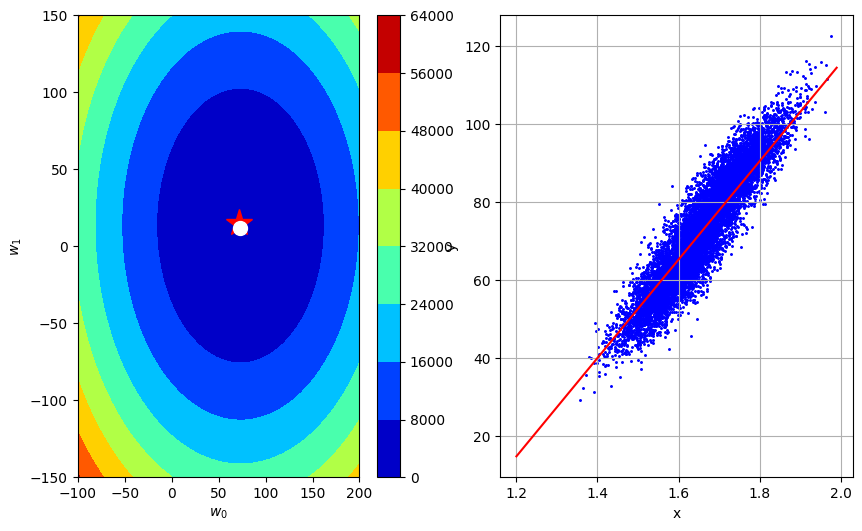

In [91]:
from ipywidgets import IntSlider, interact

def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))